In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import random
import seaborn as sns
from PIL import Image
from torchvision import transforms

# Use config and dataset functions
import sys
sys.path.insert(0, str(Path.cwd().parent))

from deep_learning_land_use_classification.config import IMAGES_DIR, LABELS_FILE
from deep_learning_land_use_classification.dataset import get_multi_label_data

train_df, test_df, val_df, class_names, num_classes = get_multi_label_data()

# Combine all data for exploration
all_df = pd.concat([train_df, test_df, val_df], ignore_index=True)

print(f"Total images: {len(all_df)}")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names.tolist()}")

Total images: 2100
Train: 1334, Val: 333, Test: 433
Number of classes: 17
Class names: ['airplane', 'bare-soil', 'buildings', 'cars', 'chaparral', 'court', 'dock', 'field', 'grass', 'mobile-home', 'pavement', 'sand', 'sea', 'ship', 'tanks', 'trees', 'water']


## Plot multilabel images

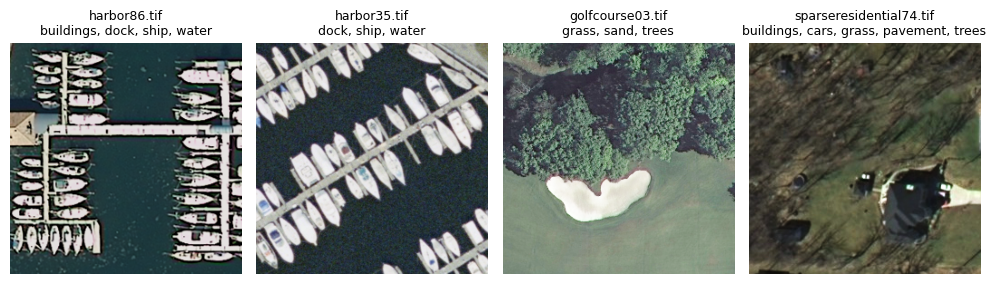

In [2]:
n_plot = 12
sampled = random.sample(range(len(all_df)), k=min(n_plot, len(all_df)))

cols = 4
rows = (n_plot + cols - 1) // cols
fig, axes = plt.subplots(1, 4, figsize=(10,10))
axes = axes.ravel() if rows > 1 or cols > 1 else [axes]

for ax, idx in zip(axes, sampled):
    row = all_df.iloc[idx]
    img_path = row["path"]
    
    # Get active labels
    labels = [class_names[i] for i in range(num_classes) if row[class_names[i]] == 1]
    label_text = ", ".join(labels) if labels else "(no labels)"
    
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(f"{Path(img_path).name}\n{label_text}", fontsize=9)
    ax.axis("off")

for ax in axes[len(sampled):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

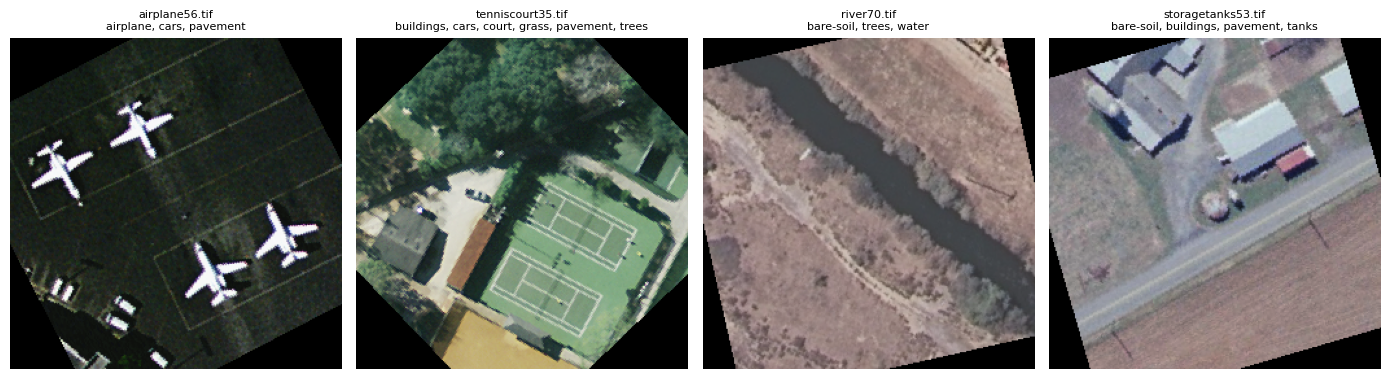

In [ ]:
train_augs = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
    transforms.RandomRotation(degrees=90)
])

n_plot_aug = 4
sampled_aug = random.sample(range(len(all_df)), k=min(n_plot_aug, len(all_df)))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.ravel()

for ax, idx in zip(axes, sampled_aug):
    row = all_df.iloc[idx]
    img_path = row["path"]

    labels = [class_names[i] for i in range(num_classes) if row[class_names[i]] == 1]
    label_text = ", ".join(labels) if labels else "(no labels)"

    img = Image.open(img_path).convert("RGB")
    aug_img = train_augs(img)

    ax.imshow(aug_img)
    ax.set_title(f"{Path(img_path).name}\n{label_text}", fontsize=8)
    ax.axis("off")

for ax in axes[len(sampled_aug):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Label count per image

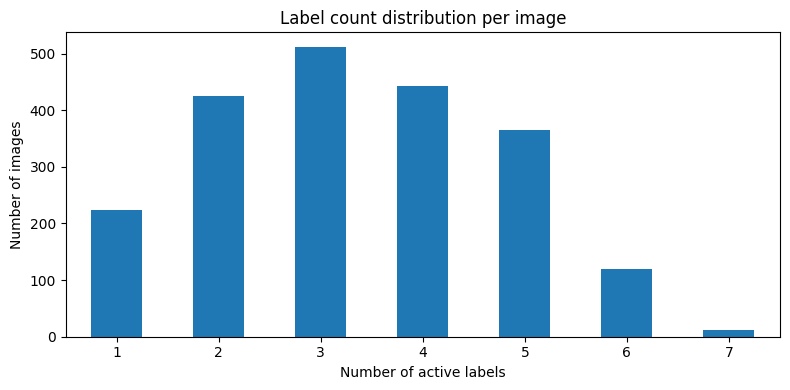

Images with labels: 2100


In [ ]:
label_counts = all_df[class_names].sum(axis=1)

plt.figure(figsize=(8, 4))
label_counts.value_counts().sort_index().plot(kind="bar")
plt.title("Label count distribution per image")
plt.xlabel("Number of active labels")
plt.ylabel("Number of images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Images with labels: {(label_counts > 0).sum()}")

## Image count per label

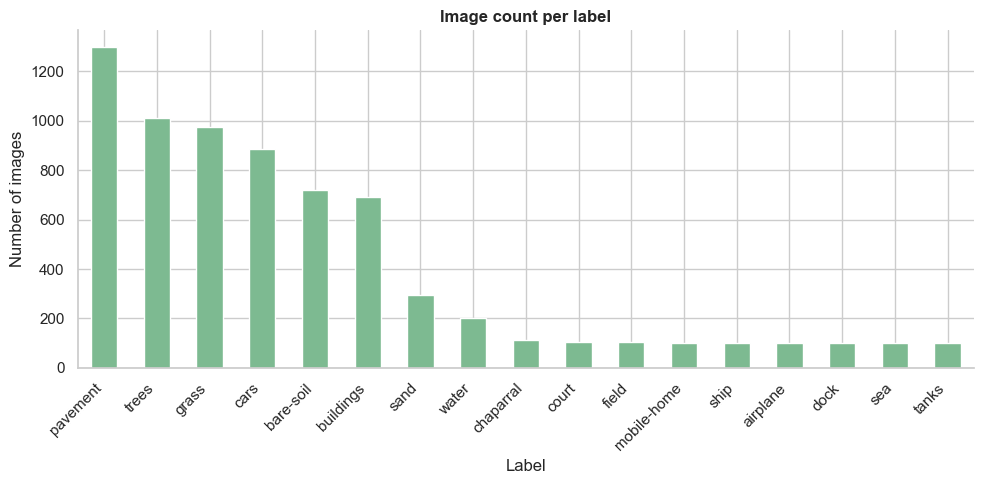

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette("crest")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

label_image_counts = all_df[class_names].sum(axis=0).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
label_image_counts.plot(kind="bar")
plt.title("Image count per label")
plt.xlabel("Label")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Unique dimensions
Turns out not *all* the images are 256x256 :))

In [ ]:
image_shapes = {}
for idx, row in all_df.iterrows():
    img = plt.imread(row["path"])
    h, w = img.shape[:2]
    image_shapes[(h, w)] = image_shapes.get((h, w), 0) + 1

print(f"Unique dimensions: {len(image_shapes)}")
for (h, w), count in sorted(image_shapes.items()):
    print(f"{h}x{w}: {count}")

Unique dimensions: 17
247x247: 9
247x256: 1
249x256: 2
251x256: 5
253x256: 3
254x256: 2
255x256: 1
256x242: 1
256x247: 1
256x249: 1
256x250: 2
256x252: 2
256x253: 6
256x254: 3
256x255: 4
256x256: 2056
257x257: 1
